# Pneumonia Detection from Chest X-Rays — CNN Pipeline
Binary classification: **NORMAL vs PNEUMONIA** using TensorFlow/Keras.

## 1. Imports & GPU Check

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import Sequential, layers
from sklearn.metrics import confusion_matrix, classification_report

# Add project root to path so src.* imports work from the notebook
sys.path.insert(0, os.path.abspath('..'))

# GPU check — TF will use GPU automatically if available
gpus = tf.config.list_physical_devices('GPU')
print('GPUs:', gpus if gpus else 'None — running on CPU')

I0000 00:00:1773812481.242497  275600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773812481.243962  275600 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773812481.305404  275600 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773812483.089877  275600 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

GPUs: None — running on CPU


E0000 00:00:1773812483.668364  275600 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773812483.669057  275985 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773812483.712948  275600 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 2. Configuration

In [2]:
DATA_DIR   = '../data/raw/chest_xray'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
VAL_DIR    = os.path.join(DATA_DIR, 'val')
TEST_DIR   = os.path.join(DATA_DIR, 'test')
MODEL_PATH = '../models/pneumonia_cnn.keras'
PLOTS_DIR  = '../results/plots'

os.makedirs('../models', exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
CLASSES     = ['NORMAL', 'PNEUMONIA']

print('Dataset folders:', os.listdir(DATA_DIR))

Dataset folders: ['.DS_Store', 'val', 'train', 'test']


## 3. Data Preprocessing & Augmentation (ImageDataGenerator)

In [3]:
# Training: augmentation + rescale
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation / Test: only rescale (no augmentation)
eval_datagen = ImageDataGenerator(rescale=1./255)

common = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
              color_mode='grayscale', class_mode='binary')

train_gen = train_datagen.flow_from_directory(TRAIN_DIR, shuffle=True,  **common)
val_gen   = eval_datagen.flow_from_directory(VAL_DIR,   shuffle=False, **common)
test_gen  = eval_datagen.flow_from_directory(TEST_DIR,  shuffle=False, **common)

print(f'Train samples : {train_gen.samples}')
print(f'Val samples   : {val_gen.samples}')
print(f'Test samples  : {test_gen.samples}')
print(f'Class indices : {train_gen.class_indices}')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train samples : 5216
Val samples   : 16
Test samples  : 624
Class indices : {'NORMAL': 0, 'PNEUMONIA': 1}


## 4. Visualise Sample Images

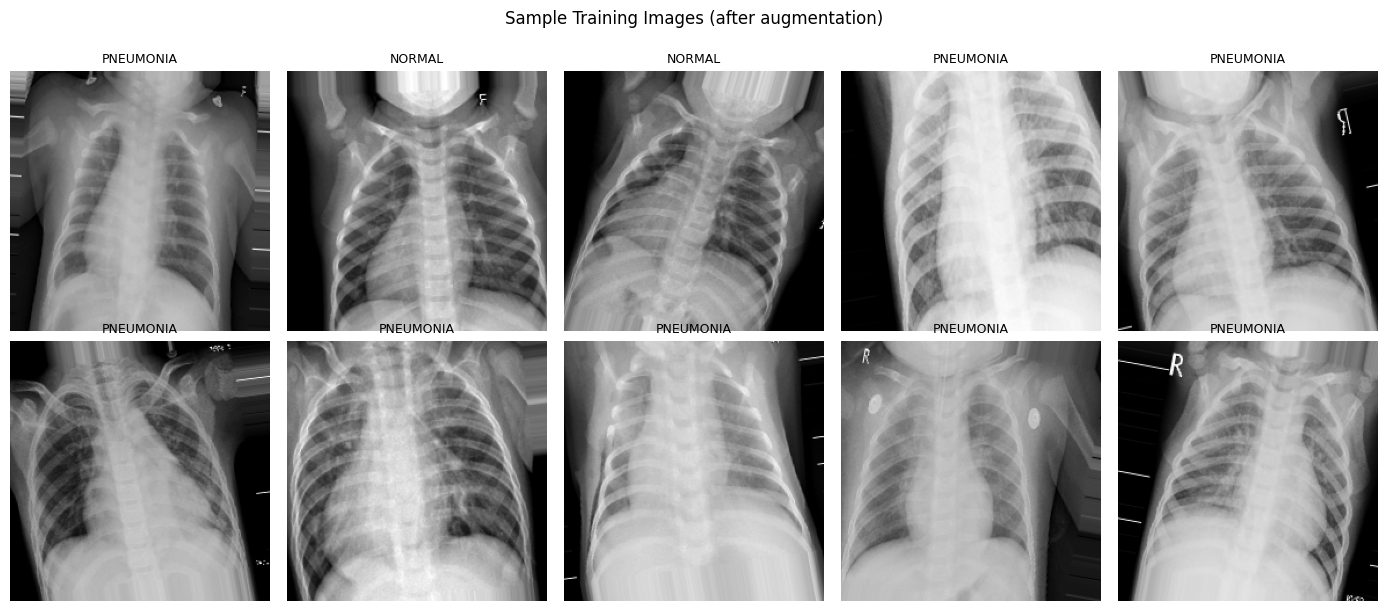

In [4]:
images, labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, img, lbl in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASSES[int(lbl)], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', y=1.01)
plt.tight_layout()
plt.show()

## 5. CNN Architecture
4 Conv blocks (32→64→128→256 filters) with BatchNorm + MaxPool,
followed by GlobalAveragePooling and a Dense head with Dropout.

In [5]:
def build_model():
    model = Sequential([
        # Block 1
        layers.Conv2D(32, 3, padding='same', activation='relu',
                      input_shape=(*IMAGE_SIZE, 1)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 4
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Classifier head — GlobalAveragePooling avoids spatial overfitting
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid'),   # binary output
    ], name='pneumonia_cnn')
    return model

model = build_model()
model.summary()

/home/CL502-21/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "pneumonia_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 488,577 (1.86 MB)

 Trainable params: 487,617 (1.86 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Compile

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 7. Callbacks

In [7]:
callbacks = [
    
   
    # Halve LR when val_loss plateaus
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    # Save the best checkpoint by val_accuracy
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1
    ),
]

## 8. Train

In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50


I0000 00:00:1773812486.282699  275600 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8341 - loss: 0.3599
Epoch 1: val_accuracy improved from None to 0.50000, saving model to ../models/pneumonia_cnn.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.8602 - loss: 0.3079 - val_accuracy: 0.5000 - val_loss: 8.7050 - learning_rate: 0.0010
Epoch 2/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9003 - loss: 0.2389
Epoch 2: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9032 - loss: 0.2298 - val_accuracy: 0.5000 - val_loss: 10.3640 - learning_rate: 0.0010
Epoch 3/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9093 - loss: 0.2221
Epoch 3: val_accuracy did not improve from 0.50000
163/163 ━━━━━━━━━━━━━━━━━━━━ 242s 1s/step - accuracy: 0.9089 - loss: 0.2188 - val_accuracy: 0.5000 - val_loss: 9.2473 - learning_rate: 0.0010
Epoch 4/50
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9013 - loss: 0.2233
Epoch 4: val_accuracy did not improve from 

## 9. Training Curves

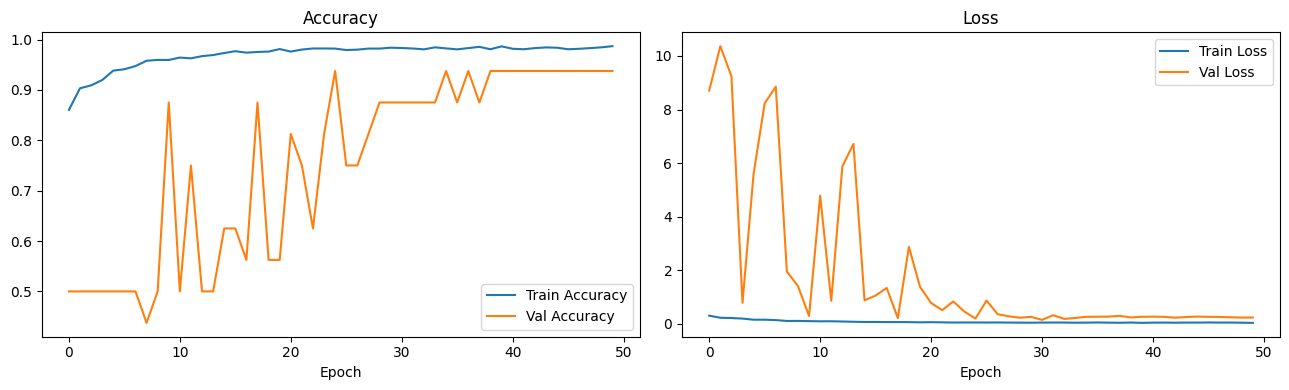

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (train_key, val_key), title in zip(
    axes,
    [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
    ['Accuracy', 'Loss']
):
    ax.plot(history.history[train_key], label=f'Train {title}')
    ax.plot(history.history[val_key],   label=f'Val {title}')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 10. Evaluate on Test Set

In [10]:
test_loss, test_acc = model.evaluate(test_gen, verbose=1)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 286ms/step - accuracy: 0.9038 - loss: 0.3585

Test Loss     : 0.3585
Test Accuracy : 0.9038


## 11. Confusion Matrix, Precision, Recall & F1-Score

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step

── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

      NORMAL       0.88      0.86      0.87       234
   PNEUMONIA       0.92      0.93      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624



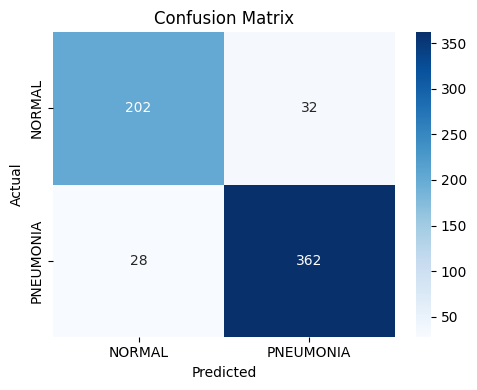

In [11]:
test_gen.reset()
y_true = test_gen.classes
y_prob = model.predict(test_gen, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print('\n── Classification Report ──────────────────────────────────────')
print(classification_report(y_true, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 12. Predict on a Single Image

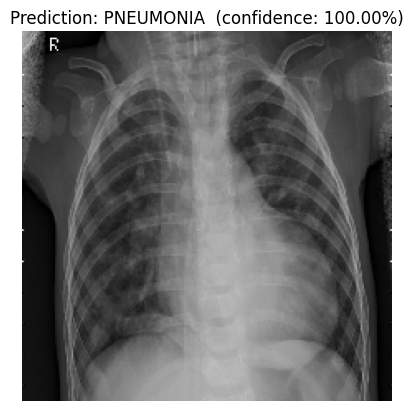

Result → PNEUMONIA  |  Confidence: 100.00%


In [12]:
def predict_single(img_path: str, threshold: float = 0.5):
    """Load one chest X-ray and return the predicted class + confidence."""
    img = load_img(img_path, color_mode='grayscale', target_size=IMAGE_SIZE)
    arr = img_to_array(img) / 255.0          # rescale to [0, 1]
    arr = np.expand_dims(arr, axis=0)        # add batch dimension → (1, 224, 224, 1)

    prob = model.predict(arr, verbose=0)[0][0]
    label = CLASSES[int(prob >= threshold)]

    plt.imshow(img, cmap='gray')
    plt.title(f'Prediction: {label}  (confidence: {prob:.2%})', fontsize=12)
    plt.axis('off')
    plt.show()

    return label, float(prob)


# ── Example usage ─────────────────────────────────────────────────────────────
# Replace the path below with any chest X-ray image on your machine.
SAMPLE_IMAGE = os.path.join(TEST_DIR, 'PNEUMONIA',
                             os.listdir(os.path.join(TEST_DIR, 'PNEUMONIA'))[0])

label, confidence = predict_single(SAMPLE_IMAGE)
print(f'Result → {label}  |  Confidence: {confidence:.2%}')

## 13. Save / Load Model

In [13]:
# Best checkpoint was already saved by ModelCheckpoint callback.
# To reload it later:
# loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f'Best model saved at: {MODEL_PATH}')

Best model saved at: ../models/pneumonia_cnn.keras
